Task 3 – Train a two-hidden-unit MLP

In [45]:
import numpy as np
import matplotlib.pyplot as plt
X = np.array([[-2.], [-1.], [-0.5], [0.5], [1.], [2.]])
y = np.abs(X)
initial = {
"W1": np.array([[0.5, -0.5]]),
"b1": np.array([0., 0.]),
"W2": np.array([[0.5], [0.5]]),
"b2": np.array([0.]),
}

A. Forward pass. 

Implement forward(params, X), returning Z1, H, Yhat, and
mse(params, X, y), returning a scalar. Shapes: Z1, H are (6,2); Yhat, y are (6,1).
Print the initial predictions and mean loss

In [ ]:
def ReLU(z):
    return np.maximum(0, z)


def forward(initial, X):
    z1 = X @ initial["W1"] + initial["b1"]
    H = ReLU(z1)
    y_hat = H @ initial["W2"] + initial["b2"]

    return z1, H, y_hat


def MSE(params, X, y):
    Z1, H, Yhat = forward(params, X)

    assert Yhat.shape == y.shape

    return np.mean((y - Yhat)**2)


Z1, H, y_hat = forward(initial, X)

assert Z1.shape == (6, 2)
assert H.shape == (6, 2)
assert y_hat.shape == (6, 1)
assert y.shape == (6, 1)

print("Initial predictions:")
print(y_hat)

print("Initial MSE:")
print(MSE(initial, y, y_hat))

Initial predictions:
[[0.5  ]
 [0.25 ]
 [0.125]
 [0.125]
 [0.25 ]
 [0.5  ]]
Initial MSE:
0.0


B. Backward pass. Implement the supplied gradients (no need to derive general
backprop):

In [47]:
def gradients(params, X, y):

    Z1, H, Yhat = forward(params, X)

    N = len(X)

    G = (2 / N) * (Yhat - y)

    gW2 = H.T @ G
    gb2 = np.sum(G, axis=0)

    D = (G @ params["W2"].T) * (Z1 > 0)

    gW1 = X.T @ D
    gb1 = np.sum(D, axis=0)

    return {
        "W1": gW1,
        "b1": gb1,
        "W2": gW2,
        "b2": gb2
    }

C. Run the experiment.

1. Copy the initial parameters. Print all four gradients at initialization and check
that each matches its parameter’s shape.
2. Make one simultaneous update, learning rate 0.05. Print the old and newly recomputed loss.
3
3. Reset every parameter to its initial value. Train for exactly 300 full-batch updates at lr = 0.05, saving the loss before and after every update – 301 values
total.
4. Plot loss vs. update number (0–300). Print final predictions and final MSE; confirm it’s lower than the initial loss.


In [48]:
params = {
    name: value.copy()
    for name, value in initial.items()
}

grads = gradients(params, X, y)

for name in grads:
    print(name, "=", grads[name])
    print("gradient shape:", grads[name].shape)
    print("parameter shape:", params[name].shape)
    print()

    assert grads[name].shape == params[name].shape

W1 = [[-0.65625  0.65625]]
gradient shape: (1, 2)
parameter shape: (1, 2)

b1 = [-0.4375 -0.4375]
gradient shape: (2,)
parameter shape: (2,)

W2 = [[-0.65625]
 [-0.65625]]
gradient shape: (2, 1)
parameter shape: (2, 1)

b2 = [-1.75]
gradient shape: (1,)
parameter shape: (1,)



In [49]:
old_loss = MSE(params, X, y)
grads = gradients(params, X, y)

lr = 0.05
params = {
    name: params[name] - lr * grads[name]
    for name in params
}

new_loss = MSE(params, X, y)

print("Old loss:", old_loss)
print("New loss:", new_loss)

Old loss: 0.984375
New loss: 0.7415765000805258


In [50]:
params = {
    name: value.copy()
    for name, value in initial.items()
}

history = [MSE(params, X, y)]

for step in range(300):

    grads = gradients(params, X, y)

    params = {
        name: params[name] - 0.05 * grads[name]
        for name in params
    }

    history.append(MSE(params, X, y))

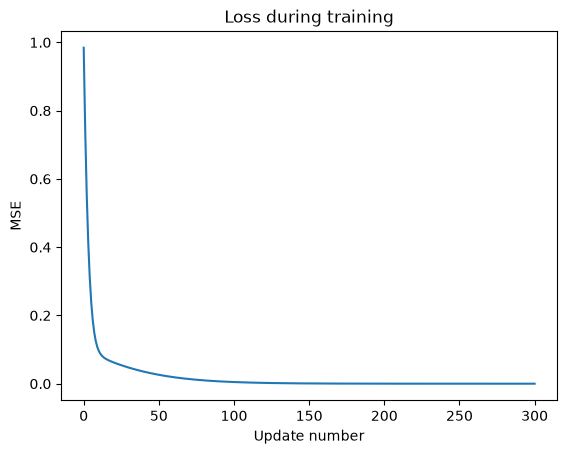

Final predictions:
[[1.99845228]
 [1.00078542]
 [0.50195199]
 [0.50195199]
 [1.00078542]
 [1.99845228]]
Targets:
[[2. ]
 [1. ]
 [0.5]
 [0.5]
 [1. ]
 [2. ]]
Initial MSE: 0.984375
Final MSE: 2.274200788567709e-06


In [51]:
plt.plot(range(301), history)

plt.xlabel("Update number")
plt.ylabel("MSE")
plt.title("Loss during training")

plt.show()

Z1, H, final_predictions = forward(params, X)

print("Final predictions:")
print(final_predictions)

print("Targets:")
print(y)

print("Initial MSE:", history[0])
print("Final MSE:", history[-1])

assert history[-1] < history[0]

X check:
[[-1.5 ]
 [-0.75]
 [ 0.75]
 [ 1.5 ]]
Predictions:
[[1.49961885]
 [0.75136871]
 [0.75136871]
 [1.49961885]]
Targets:
[[1.5 ]
 [0.75]
 [0.75]
 [1.5 ]]
Check MSE:
1.0093159510004993e-06


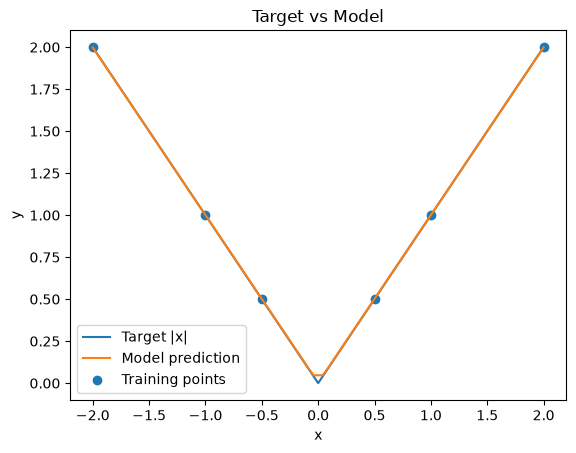

In [52]:
X_check = np.array([
    [-1.5],
    [-0.75],
    [0.75],
    [1.5]
])

y_check = np.abs(X_check)

_, _, check_predictions = forward(params, X_check)

print("X check:")
print(X_check)

print("Predictions:")
print(check_predictions)

print("Targets:")
print(y_check)

print("Check MSE:")
print(MSE(params, X_check, y_check))

X_plot = np.linspace(-2, 2, 101).reshape(-1, 1)

y_target = np.abs(X_plot)

_, _, y_model = forward(params, X_plot)

plt.plot(X_plot, y_target, label="Target |x|")
plt.plot(X_plot, y_model, label="Model prediction")

plt.scatter(X, y, label="Training points")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Target vs Model")
plt.legend()

plt.show()